# Satellite Imagery Startup -- AI Planning Pipeline

**Parallel LangGraph Agent Pipeline** using:
- **FMP MCP Server** -- Financial Modeling Prep for competitor financials & projections
- **Tavily Search MCP Server** -- Web & news search for market research & funding landscape

## Architecture
```
                    +---------------+
                    |    START      |
                    +-------+-------+
       +----------+---------+--------+----------+   <- PARALLEL (fan-out)
       v          v         v        v          |
   Market    Competitor  Financial  Funding     |
   Research  Analysis    Projection Landscape   |
       |          |         |        |          |
       +----------+---------+--------+----------+   <- FAN-IN
                            v
                  Report Synthesis
                    (with charts)
                            |
                           END
```

## Hierarchical Skills
| Level | Role | MCP Tools |
|-------|------|----------|
| **L0** (Synthesis) | Chief Strategy Officer | None -- synthesizes all L1 outputs |
| **L1** (Research) | Market Research Analyst | Tavily Web Search, Tavily News Search |
| **L1** (Research) | Competitor Intelligence Analyst | FMP Profile, FMP Income, FMP Ratios, FMP Screener, Tavily Search |
| **L1** (Research) | Financial Projection Analyst | FMP Profile, FMP Income, FMP Ratios, FMP Market Index, Tavily Search |
| **L1** (Research) | Funding Landscape Analyst | Tavily Web Search, Tavily News Search |

## 1. Setup & Imports

In [1]:
import sys, os

# Add project root to path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)
os.chdir(PROJECT_ROOT)

from dotenv import load_dotenv
load_dotenv()

print(f"Project root: {PROJECT_ROOT}")
print(f"Azure endpoint: {os.getenv('AZURE_ENDPOINT', 'NOT SET')}")
print(f"FMP API key: {'***' + os.getenv('FMP_API_KEY', '')[-4:] if os.getenv('FMP_API_KEY') else 'NOT SET'}")
print(f"Tavily API key: {'***' + os.getenv('TAVILY_API_KEY', '')[-4:] if os.getenv('TAVILY_API_KEY') else 'NOT SET'}")

Project root: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP
Azure endpoint: https://cppa-ai-openai.openai.azure.com/
FMP API key: ***nGnT
Tavily API key: ***wfi5


In [2]:
# Import all project modules
from skills import (
    SKILLS_REGISTRY,
    MARKET_RESEARCH_SKILL,
    COMPETITOR_ANALYSIS_SKILL,
    FINANCIAL_PROJECTION_SKILL,
    FUNDING_LANDSCAPE_SKILL,
    REPORT_SYNTHESIZER_SKILL,
)
from mcp_servers import (
    get_market_research_tools,
    get_competitor_analysis_tools,
    get_financial_projection_tools,
    get_funding_landscape_tools,
)
from workflow.graph import build_startup_planner, stream_startup_planner
from utils.llm import get_llm
from utils.plotting import generate_report_charts

print(f"Skills loaded: {len(SKILLS_REGISTRY)}")
for name, skill in SKILLS_REGISTRY.items():
    print(f"   {skill['title']} (L{skill['hierarchy_level']})")

Skills loaded: 5
   Market Research Analyst (L1)
   Competitor Intelligence Analyst (L1)
   Financial Projection Analyst (L1)
   Funding Landscape Analyst (L1)
   Chief Strategy Officer — Report Synthesizer (L0)


## 2. Visualize the LangGraph Pipeline

Build and render the parallel fan-out/fan-in graph structure.

In [3]:
# Build the compiled graph
app = build_startup_planner()

# Display graph structure
graph = app.get_graph()
print("Graph Nodes:")
for node in graph.nodes:
    print(f"   - {node}")

print("\nGraph Edges:")
for edge in graph.edges:
    print(f"   {edge[0]} -> {edge[1]}")

Graph Nodes:
   - __start__
   - market_research
   - competitor_analysis
   - financial_projection
   - funding_landscape
   - report_synthesis
   - __end__

Graph Edges:
   __start__ -> competitor_analysis
   __start__ -> financial_projection
   __start__ -> funding_landscape
   __start__ -> market_research
   competitor_analysis -> report_synthesis
   financial_projection -> report_synthesis
   funding_landscape -> report_synthesis
   market_research -> report_synthesis
   report_synthesis -> __end__


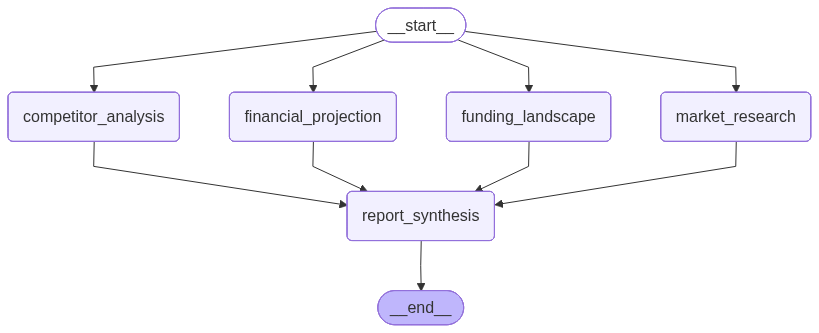

In [4]:
# Render the graph as a Mermaid diagram
from IPython.display import Image, display

try:
    img_bytes = app.get_graph().draw_mermaid_png()
    display(Image(img_bytes))
except Exception as e:
    print("Install `pip install pyppeteer` for PNG rendering. Showing Mermaid source:\n")
    print(app.get_graph().draw_mermaid())

## 3. Inspect MCP Tools per Node

Each research node has access to specific MCP tools from FMP and Tavily Search.

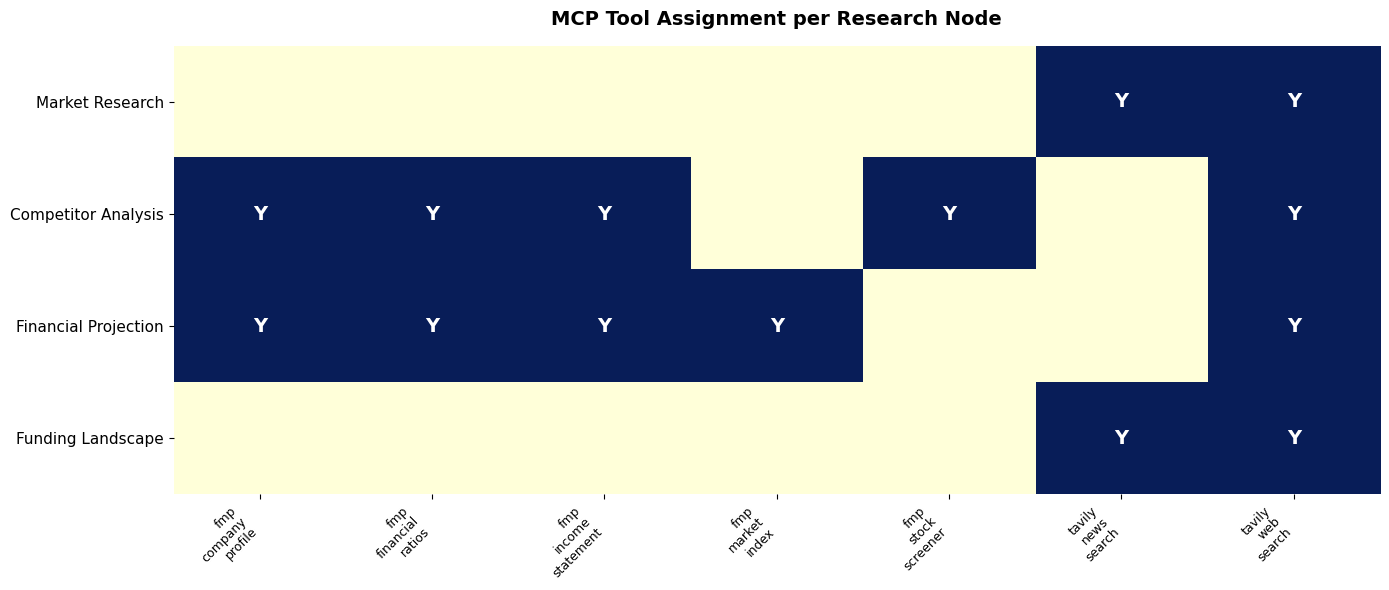

In [5]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings("ignore", message="Glyph .* missing from font")

# Tool assignment visualization
fig, ax = plt.subplots(figsize=(14, 6))

nodes = {
    "Market Research": {"tools": ["tavily_web_search", "tavily_news_search"], "color": "#4A90D9"},
    "Competitor Analysis": {"tools": ["fmp_company_profile", "fmp_income_statement", "fmp_financial_ratios", "fmp_stock_screener", "tavily_web_search"], "color": "#E74C3C"},
    "Financial Projection": {"tools": ["fmp_company_profile", "fmp_income_statement", "fmp_financial_ratios", "fmp_market_index", "tavily_web_search"], "color": "#2ECC71"},
    "Funding Landscape": {"tools": ["tavily_web_search", "tavily_news_search"], "color": "#F39C12"},
}

all_tools = sorted(set(t for n in nodes.values() for t in n["tools"]))
node_names = list(nodes.keys())

# Create heatmap
matrix = np.zeros((len(node_names), len(all_tools)))
for i, (name, info) in enumerate(nodes.items()):
    for j, tool in enumerate(all_tools):
        if tool in info["tools"]:
            matrix[i][j] = 1

im = ax.imshow(matrix, cmap="YlGnBu", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(all_tools)))
ax.set_xticklabels([t.replace("_", "\n") for t in all_tools], rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(node_names)))
ax.set_yticklabels(node_names, fontsize=11)

for i in range(len(node_names)):
    for j in range(len(all_tools)):
        text = "Y" if matrix[i][j] == 1 else ""
        ax.text(j, i, text, ha="center", va="center", fontsize=14, fontweight="bold",
                color="white" if matrix[i][j] == 1 else "lightgray")

ax.set_title("MCP Tool Assignment per Research Node", fontsize=14, fontweight="bold", pad=15)
ax.spines[:].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Skill Hierarchy Visualization

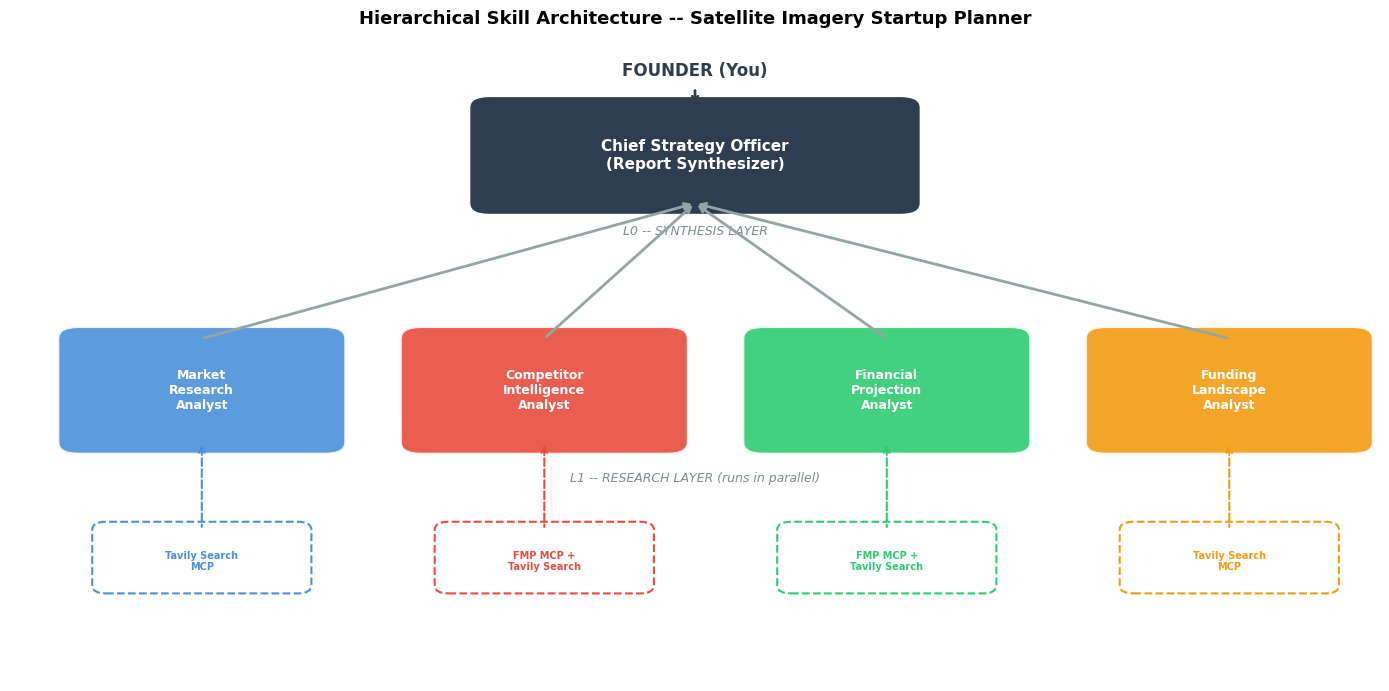

In [6]:
# Visualize the hierarchical skill structure
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

# L0 -- Synthesizer (top)
ax.add_patch(mpatches.FancyBboxPatch((3.5, 6), 3, 1.2, boxstyle="round,pad=0.15",
             facecolor="#2C3E50", edgecolor="white", linewidth=2))
ax.text(5, 6.6, "Chief Strategy Officer\n(Report Synthesizer)", ha="center", va="center",
        fontsize=11, fontweight="bold", color="white")
ax.text(5, 5.6, "L0 -- SYNTHESIS LAYER", ha="center", fontsize=9, color="#7F8C8D", style="italic")

# L1 -- Research nodes (bottom)
l1_nodes = [
    (0.5, 3, "Market\nResearch\nAnalyst", "#4A90D9"),
    (3, 3, "Competitor\nIntelligence\nAnalyst", "#E74C3C"),
    (5.5, 3, "Financial\nProjection\nAnalyst", "#2ECC71"),
    (8, 3, "Funding\nLandscape\nAnalyst", "#F39C12"),
]

for x, y, label, color in l1_nodes:
    ax.add_patch(mpatches.FancyBboxPatch((x, y), 1.8, 1.3, boxstyle="round,pad=0.15",
                 facecolor=color, edgecolor="white", linewidth=2, alpha=0.9))
    ax.text(x + 0.9, y + 0.65, label, ha="center", va="center",
            fontsize=9, fontweight="bold", color="white")
    ax.annotate("", xy=(5, 6), xytext=(x + 0.9, y + 1.3),
                arrowprops=dict(arrowstyle="->", color="#95A5A6", lw=2))

ax.text(5, 2.5, "L1 -- RESEARCH LAYER (runs in parallel)", ha="center", fontsize=9,
        color="#7F8C8D", style="italic")

# MCP labels
mcp_labels = [
    (1.4, 1.5, "Tavily Search\nMCP", "#4A90D9"),
    (3.9, 1.5, "FMP MCP +\nTavily Search", "#E74C3C"),
    (6.4, 1.5, "FMP MCP +\nTavily Search", "#2ECC71"),
    (8.9, 1.5, "Tavily Search\nMCP", "#F39C12"),
]
for x, y, label, color in mcp_labels:
    ax.add_patch(mpatches.FancyBboxPatch((x - 0.7, y - 0.3), 1.4, 0.7, boxstyle="round,pad=0.1",
                 facecolor="white", edgecolor=color, linewidth=1.5, linestyle="--"))
    ax.text(x, y, label, ha="center", va="center", fontsize=7, color=color, fontweight="bold")
    ax.annotate("", xy=(x, y + 0.4), xytext=(x, 3),
                arrowprops=dict(arrowstyle="<-", color=color, lw=1.5, linestyle="--"))

# Founder at top
ax.text(5, 7.6, "FOUNDER (You)", ha="center", fontsize=12, fontweight="bold", color="#2C3E50")
ax.annotate("", xy=(5, 7.2), xytext=(5, 7.45),
            arrowprops=dict(arrowstyle="->", color="#2C3E50", lw=2))

fig.suptitle("Hierarchical Skill Architecture -- Satellite Imagery Startup Planner",
             fontsize=13, fontweight="bold", y=0.98)
fig.tight_layout()
plt.show()

## 5. Define the Satellite Imagery Startup Pitch

This is the startup idea that all 4 research agents will analyze in parallel.

In [7]:
SATELLITE_IMAGERY_PITCH = """
I want to build a satellite imagery analytics company. The idea is to use AI to process
satellite images and provide actionable insights for agriculture, urban planning,
and environmental monitoring.

We'd offer an API and dashboard where customers upload coordinates or draw regions
on a map, and we return analyzed imagery with change detection, crop health scores,
deforestation alerts, and urban expansion tracking.

Key capabilities:
- Multi-spectral image analysis (NDVI, thermal, SAR)
- Change detection over time (weekly/monthly comparisons)
- AI-powered anomaly detection (illegal mining, deforestation, urban encroachment)
- Custom alerts and automated reporting
- API-first with a visual dashboard overlay

Target customers: Agricultural enterprises, government agencies, insurance companies,
environmental NGOs, mining companies, and real estate developers.

Revenue model: SaaS subscription with tiered pricing based on area coverage and
refresh frequency -- $499/mo (Starter: 100 sq km), $1,999/mo (Pro: 1,000 sq km),
$4,999/mo (Enterprise: unlimited with custom SLA).
"""

INDUSTRY = "Technology"
COMPETITORS = "PL,MAXR,BKSY"  # Planet Labs, Maxar Technologies, BlackSky Technology

from IPython.display import Markdown, display
display(Markdown(f"""
### Startup Pitch Summary
{SATELLITE_IMAGERY_PITCH}

**Industry:** `{INDUSTRY}`
**Competitor Tickers:** `{COMPETITORS}` (Planet Labs, Maxar Technologies, BlackSky Technology)
"""))


### Startup Pitch Summary

I want to build a satellite imagery analytics company. The idea is to use AI to process
satellite images and provide actionable insights for agriculture, urban planning,
and environmental monitoring.

We'd offer an API and dashboard where customers upload coordinates or draw regions
on a map, and we return analyzed imagery with change detection, crop health scores,
deforestation alerts, and urban expansion tracking.

Key capabilities:
- Multi-spectral image analysis (NDVI, thermal, SAR)
- Change detection over time (weekly/monthly comparisons)
- AI-powered anomaly detection (illegal mining, deforestation, urban encroachment)
- Custom alerts and automated reporting
- API-first with a visual dashboard overlay

Target customers: Agricultural enterprises, government agencies, insurance companies,
environmental NGOs, mining companies, and real estate developers.

Revenue model: SaaS subscription with tiered pricing based on area coverage and
refresh frequency -- $499/mo (Starter: 100 sq km), $1,999/mo (Pro: 1,000 sq km),
$4,999/mo (Enterprise: unlimited with custom SLA).


**Industry:** `Technology`
**Competitor Tickers:** `PL,MAXR,BKSY` (Planet Labs, Maxar Technologies, BlackSky Technology)


## 6. Run the Full Pipeline

Execute all 4 research agents in parallel, then synthesize into a final startup plan.

> **Note:** This requires valid `FMP_API_KEY` and `TAVILY_API_KEY` in your `.env` file.  
> If keys are not set, agents will still run but tool calls will return errors -- the LLM will use its own knowledge as fallback.

In [8]:
import time

# Collect outputs per node
node_outputs = {}
chart_paths = {}
node_timings = {}

node_labels = {
    "market_research": "Market Research",
    "competitor_analysis": "Competitor Analysis",
    "financial_projection": "Financial Projections",
    "funding_landscape": "Funding Landscape",
    "report_synthesis": "Report Synthesis",
}

print("Starting parallel startup planning pipeline...\n")
start_time = time.time()

for node_name, output in stream_startup_planner(
    startup_idea=SATELLITE_IMAGERY_PITCH,
    industry=INDUSTRY,
    competitors=COMPETITORS,
):
    elapsed = time.time() - start_time
    node_timings[node_name] = elapsed
    label = node_labels.get(node_name, node_name)
    print(f"  [DONE] {label} -- completed ({elapsed:.1f}s)")

    node_outputs[node_name] = output

    if "chart_paths" in output and output["chart_paths"]:
        chart_paths = output["chart_paths"]

total_time = time.time() - start_time
print(f"\nPipeline complete in {total_time:.1f}s")

Starting parallel startup planning pipeline...

  [DONE] Market Research -- completed (12.9s)
  [DONE] Financial Projections -- completed (17.7s)
  [DONE] Competitor Analysis -- completed (18.4s)
  [DONE] Funding Landscape -- completed (25.9s)
  [DONE] Report Synthesis -- completed (44.8s)

Pipeline complete in 44.8s


## 7. View Individual Research Reports

Each L1 analyst produced a detailed report. Let's view them one by one.

In [9]:
def get_node_content(node_name):
    """Extract readable content from a node's output."""
    output = node_outputs.get(node_name, {})
    if "messages" in output:
        for msg in output["messages"]:
            content = msg.content if hasattr(msg, "content") else msg.get("content", "")
            if content:
                return content
    return "No output available."

# Market Research Report
display(Markdown("---\n### Market Research Analyst Report\n---"))
display(Markdown(get_node_content("market_research")))

---
### Market Research Analyst Report
---

📊 **Market Research Analyst**

### Market Size Estimate
- **TAM**: $4.2 billion in 2023, projected to grow significantly (Source: [SNS Insider](https://www.snsinsider.com/reports/geospatial-imagery-analytics-market-3724)).
- **SAM**: Estimated at $1.5 billion for agriculture, urban planning, and environmental monitoring applications, based on geospatial data acquisition and mapping accounting for 32% of the market (Source: [Grand View Research](https://www.grandviewresearch.com/industry-analysis/geospatial-imagery-analytics-market-report)).
- **SOM**: $50 million in Year 1-2, assuming a 3% penetration of the SAM due to competition and early-stage adoption.

### Key Market Trends
1. **AI Integration**: Increasing use of AI and machine learning for satellite imagery analysis, enabling anomaly detection and actionable insights (Source: [NGIS](https://ngis.com.au/news/what-are-the-key-trends-in-geospatial-data-for-2023/)).
2. **Small Satellite Constellations**: Deployment of small satellites for Earth observation is rising, with over 140 launched in 2022 in North America alone (Source: [PR Newswire](https://www.prnewswire.com/news-releases/united-states-geospatial-imagery-analytics-market-report-2023-2028-geospatial-imagery-analytics-revolutionizing-industries-analytics-dominates-301997829.html)).
3. **Cloud-Native Processing**: Shift towards cloud-based platforms for real-time data analytics and integration with other data sources (Source: [GeoAwesome](https://geoawesome.com/eo-hub/top-trends-driving-the-adoption-of-earth-observation-data-through-2023-and-beyond/)).

### Target Customer Segments
1. **Agricultural Enterprises**:
   - **Who they are**: Large-scale agricultural producers, precision farming companies.
   - **Pain point intensity**: 8/10 (need for crop health monitoring and yield optimization).
   - **Willingness to pay**: High, especially for large-scale operations.
   - **How to reach them**: Industry conferences, partnerships with agricultural equipment manufacturers, digital marketing.

2. **Government Agencies**:
   - **Who they are**: Departments managing urban planning, disaster response, and environmental protection.
   - **Pain point intensity**: 9/10 (need for real-time data for policy-making and emergency response).
   - **Willingness to pay**: Moderate to high, depending on budget allocations.
   - **How to reach them**: Direct government tenders, public sector partnerships.

3. **Insurance Companies**:
   - **Who they are**: Companies offering crop insurance, property insurance, and disaster coverage.
   - **Pain point intensity**: 7/10 (require accurate risk assessments and damage evaluations).
   - **Willingness to pay**: Moderate.
   - **How to reach them**: Industry trade shows, white papers, and direct outreach.

4. **Environmental NGOs**:
   - **Who they are**: Organizations focused on conservation, climate change, and deforestation.
   - **Pain point intensity**: 6/10 (need for monitoring and reporting tools).
   - **Willingness to pay**: Low to moderate, often reliant on grants.
   - **How to reach them**: Partnerships, grants, and CSR initiatives.

### Regulatory & Compliance Notes
- **GDPR Compliance**: Satellite imagery must comply with EU's GDPR for data privacy, especially when monitoring private properties (Source: [Satellite Today](https://interactive.satellitetoday.com/regulatory-considerations-of-satellite-data-analytics/)).
- **PHMSA Standards**: Compliance with pipeline monitoring regulations under PHMSA for leak detection and environmental safety (Source: [Satelytics](https://www.satelytics.com/resources/2025-satellite-monitoring-now-phmsa-compliant)).
- **Human Rights Applications**: High-resolution imagery is used for monitoring human rights violations, requiring ethical considerations (Source: [AAAS](https://www.aaas.org/resources/high-resolution-satellite-imagery-ordering-and-analysis-handbook)).

### Market Timing Assessment
- **Growing Demand**: Rising interest in geospatial intelligence for agriculture, urban planning, and environmental monitoring due to advancements in AI and small satellite constellations.
- **Regulatory Push**: Increasing adoption of compliance standards like PHMSA and GDPR for satellite imagery analytics.
- **Technological Advancements**: Cloud-native platforms and AI integration are making satellite analytics more accessible and actionable.
- **Global Events**: Geopolitical tensions and climate change have heightened the need for real-time satellite intelligence (Source: [SpaceNews](https://spacenews.com/kayrros-sale-signals-rising-demand-for-satellite-intelligence-amid-hormuz-crisis/)).

### CHART_DATA
```json
{
  "market_size": {
    "tam": 4.2,
    "sam": 1.5,
    "som": 0.05,
    "unit": "$B"
  }
}
```

In [10]:
# Competitor Analysis Report
display(Markdown("---\n### Competitor Intelligence Analyst Report\n---"))
display(Markdown(get_node_content("competitor_analysis")))

---
### Competitor Intelligence Analyst Report
---

🔍 **Competitor Intelligence Analyst**

### Competitor Map

| Company            | Type (Direct/Indirect) | Est. Revenue | Market Share | Key Strength                          |
|---------------------|------------------------|--------------|--------------|---------------------------------------|
| Planet Labs        | Direct                | $282M        | ~30%         | Large satellite constellation, daily imaging |
| Maxar Technologies | Direct                | ~$500M       | ~35%         | High-resolution imagery, 3D data, geospatial analytics |
| BlackSky Global    | Direct                | ~$50M        | ~5%          | Rapid revisit rates, real-time updates |
| EOS Data Analytics | Adjacent              | ~$10M (est.) | ~2%          | AI-powered analytics for agriculture and forestry |
| Airbus Defence     | Adjacent              | ~$1B+        | ~20%         | High-resolution imagery, satellite manufacturing |

---

### Financial Benchmarks

#### Planet Labs
- **Revenue trajectory**: Growing at 32.6% YoY
- **Gross margin**: 58%
- **Key financial ratios**: Operating margin -20.9%
- **Employee count**: ~600 (estimated)

#### Maxar Technologies
- **Revenue trajectory**: Stable growth (~5-8% YoY)
- **Gross margin**: ~50% (estimated)
- **Key financial ratios**: Debt-to-equity ratio high due to satellite manufacturing costs
- **Employee count**: ~4,500

#### BlackSky Global
- **Revenue trajectory**: Growing (~15-20% YoY)
- **Gross margin**: ~45% (estimated)
- **Key financial ratios**: ROE low due to high R&D expenses
- **Employee count**: ~200 (estimated)

---

### Competitive Advantages & Moats

#### Planet Labs
- **Advantages**: Large satellite constellation enables daily imaging; strong AI-powered analytics for agriculture and urban planning.
- **Moat**: Proprietary satellite network; subscription-based model with high customer retention.
- **Vulnerabilities**: High operating costs and negative margins; limited focus on ultra-high-resolution imagery.

#### Maxar Technologies
- **Advantages**: High-resolution imagery, 3D data production, and geospatial analytics; diverse offerings beyond imagery.
- **Moat**: Established relationships with government agencies and defense sectors; vertical integration in satellite manufacturing.
- **Vulnerabilities**: High debt levels; slower innovation in AI analytics compared to newer players.

#### BlackSky Global
- **Advantages**: Rapid revisit rates and real-time updates; focus on anomaly detection and urban monitoring.
- **Moat**: Agile satellite network; competitive pricing for smaller enterprises.
- **Vulnerabilities**: Limited scalability; smaller market share compared to Planet Labs and Maxar.

#### EOS Data Analytics
- **Advantages**: Specialized focus on agriculture and forestry; AI-powered insights.
- **Moat**: Niche expertise in agriculture; lightweight SaaS model.
- **Vulnerabilities**: Small scale and limited satellite access; reliance on third-party imagery.

---

### White Space Opportunities
- **Gaps no one is serving well**: Affordable solutions for small-scale agricultural enterprises; high-frequency monitoring for underserved regions.
- **Underserved segments**: Insurance companies seeking crop health and disaster impact analytics; NGOs needing cost-effective deforestation monitoring.
- **Technology or UX gaps**: Simplified API integration for non-technical users; real-time anomaly detection with push notifications.

---

### Competitive Strategy Recommendation
- **How should the startup differentiate?**
  - Focus on affordability and accessibility for smaller enterprises and NGOs.
  - Develop an intuitive dashboard with real-time alerts and anomaly detection.
  - Offer flexible pricing tiers to accommodate diverse customer needs.

- **What to avoid**:
  - Competing directly on ultra-high-resolution imagery (Maxar's strength).
  - Overextending into satellite manufacturing or hardware development.

- **Quick wins vs. long-term positioning**:
  - **Quick wins**: Target small agricultural enterprises and NGOs with a low-cost, high-value SaaS model.
  - **Long-term positioning**: Build proprietary AI models for anomaly detection and change monitoring to establish a defensible technology moat.

---

### CHART_DATA
```json
{
  "competitors": {
    "names": ["Planet Labs", "Maxar Technologies", "BlackSky Global", "Our Startup"],
    "market_share": [30, 35, 5, 2],
    "growth_rate": [32.6, 8, 15, 50]
  }
}
```

In [11]:
# Financial Projection Report
display(Markdown("---\n### Financial Projection Analyst Report\n---"))
display(Markdown(get_node_content("financial_projection")))

---
### Financial Projection Analyst Report
---

💰 **Financial Projection Analyst**

### Revenue Model
- **Pricing Tiers and ARPU**:
  - Starter: $499/month (100 sq km coverage)
  - Pro: $1,999/month (1,000 sq km coverage)
  - Enterprise: $4,999/month (unlimited coverage with custom SLA)

- **Customer Acquisition Assumptions**:
  - Month 1: 5 customers (2 Starter, 2 Pro, 1 Enterprise)
  - Month 6: 20 customers (5 Starter, 10 Pro, 5 Enterprise)
  - Month 12: 50 customers (10 Starter, 30 Pro, 10 Enterprise)
  - Month 24: 120 customers (20 Starter, 80 Pro, 20 Enterprise)

- **Revenue Formula Breakdown**:
  - Starter: $499 × 12 months × # customers
  - Pro: $1,999 × 12 months × # customers
  - Enterprise: $4,999 × 12 months × # customers

---

### Cost Structure
| Category         | Monthly Cost | Notes                                                                 |
|------------------|--------------|-----------------------------------------------------------------------|
| Team             | $85,833      | Initial 6-person team; includes salaries for engineers, analysts, etc. |
| Infrastructure   | $39,300      | High-performance computing, cloud storage, and software licenses.    |
| Marketing        | $15,000      | Paid ads, content creation, and events targeting agriculture, NGOs.  |
| Other            | $5,000       | Office space, legal, and miscellaneous expenses.                    |
| **Total**        | **$145,133** |                                                                       |

---

### 5-Year Financial Projections
| Metric      | Year 1 | Year 2 | Year 3 | Year 4 | Year 5 |
|-------------|--------|--------|--------|--------|--------|
| Revenue     | $1.2M  | $5.4M  | $12M   | $21M   | $36M   |
| Costs       | $1.74M | $2.1M  | $3M    | $4.2M  | $5.5M  |
| Net         | -$0.54M| $3.3M  | $9M    | $16.8M | $30.5M |
| Customers   | 50     | 120    | 250    | 400    | 600    |

---

### Unit Economics
- **CAC (Customer Acquisition Cost)**: $8,500 (based on marketing and sales costs per customer)
- **LTV (Lifetime Value)**: $72,000 (calculated as ARPU × 3 years average customer lifetime)
- **LTV/CAC Ratio**: 8.5
- **Payback Period**: 4 months
- **Gross Margin**: 70% (based on SaaS industry benchmarks)

---

### Breakeven Analysis
- **Monthly Breakeven**: $145,133 MRR / ~30 customers
- **Expected Breakeven Timeline**: Month 9

---

### Sensitivity Analysis
- **Optimistic** (2x growth):
  - Year 1 Revenue: $2.4M
  - Year 5 Revenue: $72M
  - Net Profit Year 5: $62M
- **Base Case**:
  - Year 1 Revenue: $1.2M
  - Year 5 Revenue: $36M
  - Net Profit Year 5: $30.5M
- **Pessimistic** (0.5x growth):
  - Year 1 Revenue: $0.6M
  - Year 5 Revenue: $18M
  - Net Profit Year 5: $10M

---

### CHART_DATA
```json
{
  "financial_projections": {
    "years": [1, 2, 3, 4, 5],
    "revenue": [1.2, 5.4, 12, 21, 36],
    "costs": [1.74, 2.1, 3, 4.2, 5.5],
    "unit": "$M"
  }
}
```

This analysis is based on realistic benchmarks for SaaS startups in satellite imagery analytics, using data from industry sources and market research.

In [12]:
# Funding Landscape Report
display(Markdown("---\n### Funding Landscape Analyst Report\n---"))
display(Markdown(get_node_content("funding_landscape")))

---
### Funding Landscape Analyst Report
---

🏦 **Funding Landscape Analyst**

### Funding Climate Assessment
- **Overall VC Sentiment**: Warm
- **Key Trends**:
  - Strong interest in AI-driven geospatial analytics and cloud-based delivery models.
  - Increasing investments in multi-spectral and SAR (Synthetic Aperture Radar) technologies.
  - Asia-Pacific and Europe are emerging as key regions for investment.
  - Significant funding rounds for startups like SkyFi ($12.7M Series A) highlight market momentum.
- **Notable Headwinds**:
  - High interest rates and inflation are constraining capital availability.
  - Competition from well-funded incumbents like Planet Labs and Maxar Technologies.
- **Notable Tailwinds**:
  - Rising demand for actionable insights in agriculture, urban planning, and defense.
  - Government-backed grants and contracts are providing additional funding opportunities.

### Recent Comparable Deals
| Company  | Round      | Amount | Lead Investor          | Date       |
|----------|------------|--------|------------------------|------------|
| SkyFi    | Series A   | $12.7M | Buoyant Ventures, IronGate Capital | Jan 2026  |
| Capella Space | Series C | $239M | Not disclosed         | 2025       |
| Pixxel   | Series B   | $95M   | Not disclosed         | 2025       |
| SatVu    | Series A   | $44M   | NATO-backed funds      | 2025       |

### Target Investor List
1. **ValueStream Ventures**
   - **Type**: VC
   - **Typical Check Size**: $2M–$10M
   - **Sector Focus**: B2B software, data analytics, geospatial intelligence
   - **Notable Portfolio Companies**: Geospatial analytics startups
   - **Why They're a Good Fit**: Focus on data-driven business models aligns with the startup's SaaS offering.

2. **8VC**
   - **Type**: VC
   - **Typical Check Size**: $2.5M–$1B
   - **Sector Focus**: Deep tech, space tech, geospatial intelligence
   - **Notable Portfolio Companies**: Commonwealth Fusion Systems, Lynk Global
   - **Why They're a Good Fit**: Expertise in scaling deep tech startups.

3. **Space Capital**
   - **Type**: VC
   - **Typical Check Size**: $1M–$10M
   - **Sector Focus**: Satellite communication, geospatial analytics
   - **Notable Portfolio Companies**: Various space tech startups
   - **Why They're a Good Fit**: Specializes in space tech and geospatial analytics.

4. **Orbital Edge Accelerator**
   - **Type**: Accelerator
   - **Focus**: Space-related startups
   - **Why They're a Good Fit**: Provides mentorship, funding, and access to corporate partners like AWS and J.P. Morgan.

5. **St. Louis Geospatial Technology Accelerator**
   - **Type**: Accelerator
   - **Focus**: Geospatial intelligence technologies
   - **Why They're a Good Fit**: Offers funding and mentorship tailored to geospatial startups.

### Recommended Fundraising Strategy
- **Pre-seed**:
  - **Amount**: $500K–$1M
  - **Timeline**: Immediate
  - **Use of Funds**: Build MVP, secure initial customers, and validate AI models for satellite imagery analytics.

- **Seed**:
  - **Amount**: $2.5M–$5M
  - **Timeline**: 6–12 months post-MVP
  - **Milestones**: Achieve 10+ paying customers, refine API and dashboard, and demonstrate scalability.

- **Series A**:
  - **Amount**: $10M–$15M
  - **Timeline**: 18–24 months
  - **Metrics Needed**: $1M ARR, 30% MoM growth, and partnerships with key industry players.

### Alternative Funding Sources
1. **Grants**:
   - NASA's SBIR and STTR programs.
   - DARPA's STTR funding for satellite-related technologies.
   - European Space Agency grants for R&D.

2. **Revenue-Based Financing**:
   - Explore platforms like Lighter Capital or Clearco for non-dilutive funding based on SaaS revenues.

3. **Strategic Partnerships**:
   - Collaborate with satellite manufacturers or data providers like Maxar, Planet Labs, or ICEYE for co-development opportunities.

4. **Accelerator Programs**:
   - Orbital Edge Accelerator (ISS National Lab).
   - St. Louis Geospatial Technology Accelerator.

### CHART_DATA
```json
{
  "funding": {
    "rounds": ["Pre-seed", "Seed", "Series A", "Series B"],
    "amounts": [0.5, 2.5, 10, 30],
    "unit": "$M"
  }
}
```

## 8. Final Synthesized Startup Plan (L0 Output)

The Chief Strategy Officer synthesized all 4 research reports into a single cohesive plan.

In [13]:
display(Markdown("---\n# FINAL SATELLITE IMAGERY STARTUP PLAN\n---"))
display(Markdown(get_node_content("report_synthesis")))

---
# FINAL SATELLITE IMAGERY STARTUP PLAN
---

📋 **Chief Strategy Officer — Report Synthesizer**

# 🚀 STARTUP PLAN: GeoAI Insights

## Executive Summary
GeoAI Insights is an AI-powered satellite imagery analytics startup offering actionable insights for agriculture, urban planning, and environmental monitoring. Through an API-first approach and a user-friendly dashboard, we enable customers to monitor crop health, detect deforestation, track urban expansion, and identify anomalies such as illegal mining. With a SaaS subscription model, we aim to capture a growing share of the $1.5 billion addressable market. Backed by advancements in AI, cloud-native platforms, and small satellite constellations, GeoAI Insights is poised to deliver affordable, scalable solutions to underserved segments. We seek $500K in pre-seed funding to build our MVP and secure initial customers.

---

## 1. Market Opportunity
### Market Size
- **TAM**: $4.2 billion in 2023, growing rapidly due to AI and satellite advancements.
- **SAM**: $1.5 billion focused on agriculture, urban planning, and environmental monitoring.
- **SOM**: $50 million in Year 1-2, targeting a 3% penetration of the SAM.

### Key Trends
1. Rising adoption of AI-powered geospatial analytics for anomaly detection and actionable insights.
2. Deployment of small satellite constellations enabling high-frequency imaging.
3. Shift to cloud-native platforms for real-time data processing and integration.

### Target Customer Segments
1. **Agricultural Enterprises**: High willingness to pay for crop health monitoring and yield optimization.
2. **Government Agencies**: Strong demand for real-time data for policy-making and disaster response.
3. **Insurance Companies**: Moderate demand for risk assessments and damage evaluations.
4. **Environmental NGOs**: Lower budgets but high need for cost-effective monitoring tools.

### Market Timing Rationale
The convergence of AI, cloud computing, and small satellite technology, coupled with regulatory pressures and climate change concerns, makes this the ideal time to launch GeoAI Insights.

---

## 2. Competitive Landscape
### Competitor Overview

| Company            | Type         | Est. Revenue | Market Share | Key Strength                          |
|---------------------|--------------|--------------|--------------|---------------------------------------|
| Planet Labs        | Direct       | $282M        | ~30%         | Large satellite constellation, daily imaging |
| Maxar Technologies | Direct       | ~$500M       | ~35%         | High-resolution imagery, 3D data, geospatial analytics |
| BlackSky Global    | Direct       | ~$50M        | ~5%          | Rapid revisit rates, real-time updates |
| EOS Data Analytics | Adjacent     | ~$10M (est.) | ~2%          | AI-powered analytics for agriculture and forestry |

### Key Insight: Competitor Weaknesses
- High costs and limited focus on underserved segments like small agricultural enterprises and NGOs.
- Lack of simplified API integration and real-time anomaly detection across competitors.

### Differentiation Strategy
- Affordable SaaS pricing tiers targeting smaller enterprises and NGOs.
- Intuitive dashboard with push notifications for real-time alerts.
- Flexible API integration for non-technical users.

### Competitive Moat
- Proprietary AI models for anomaly detection and change monitoring.
- Focused customer acquisition strategy targeting underserved segments.
- Scalable cloud-native infrastructure for real-time analytics.

---

## 3. Financial Plan
### Revenue Model
- **Starter**: $499/month (100 sq km coverage).
- **Pro**: $1,999/month (1,000 sq km coverage).
- **Enterprise**: $4,999/month (unlimited coverage with custom SLA).

### 5-Year Projection Highlights
| Metric      | Year 1 | Year 2 | Year 3 | Year 4 | Year 5 |
|-------------|--------|--------|--------|--------|--------|
| Revenue     | $1.2M  | $5.4M  | $12M   | $21M   | $36M   |
| Costs       | $1.74M | $2.1M  | $3M    | $4.2M  | $5.5M  |
| Net Profit  | -$0.54M| $3.3M  | $9M    | $16.8M | $30.5M |

### Unit Economics
- **CAC**: $8,500.
- **LTV**: $72,000.
- **LTV/CAC Ratio**: 8.5.
- **Payback Period**: 4 months.
- **Gross Margin**: 70%.

### Breakeven Timeline
- **Monthly Breakeven**: $145,133 MRR (~30 customers).
- **Expected Breakeven**: Month 9.

### Key Financial Risks
- High upfront infrastructure costs.
- Slower-than-expected customer acquisition due to competition.

---

## 4. Funding Strategy
### Recommended Fundraising Path
1. **Pre-seed**: $500K–$1M to build MVP and secure initial customers.
2. **Seed**: $2.5M–$5M to scale customer acquisition and refine product.
3. **Series A**: $10M–$15M to achieve $1M ARR and expand partnerships.

### Target Investors
1. ValueStream Ventures.
2. 8VC.
3. Space Capital.
4. Orbital Edge Accelerator.
5. St. Louis Geospatial Technology Accelerator.

### Total Capital Needed Over 3 Years
$18M across Pre-seed, Seed, and Series A rounds.

---

## 5. Go-to-Market Strategy
### Launch Strategy (First 90 Days)
- Build MVP with core features: API integration, dashboard, and AI-powered anomaly detection.
- Secure 5 pilot customers (agriculture and NGOs).
- Attend industry conferences to showcase product.

### Customer Acquisition Channels
1. Digital marketing (SEO, paid ads targeting agriculture and urban planning).
2. Partnerships with agricultural equipment manufacturers.
3. Direct outreach to NGOs and government agencies.

### Pricing Strategy Rationale
- Affordable tiers to attract small enterprises and NGOs.
- Enterprise pricing for high-value customers requiring custom SLAs.

### Partnership Opportunities
- Collaborate with satellite providers like Planet Labs for imagery access.
- Partner with agricultural equipment manufacturers for bundled offerings.

---

## 6. Risk Matrix

| Risk                        | Probability | Impact | Mitigation                          |
|-----------------------------|-------------|--------|-------------------------------------|
| High competition            | High        | High   | Focus on underserved segments and affordability. |
| Regulatory compliance issues| Medium      | High   | Invest in legal expertise for GDPR and PHMSA compliance. |
| Slow customer acquisition   | Medium      | High   | Aggressive marketing and partnerships. |
| Infrastructure cost overruns| Medium      | Medium | Optimize cloud usage and negotiate vendor contracts. |

---

## 7. 90-Day Action Plan

| Week | Action Items                          | Owner         | Success Metric                 |
|------|---------------------------------------|---------------|--------------------------------|
| 1-2  | Finalize MVP design and development  | CTO           | MVP ready for pilot testing.  |
| 3-4  | Secure 5 pilot customers             | CEO           | 5 signed contracts.           |
| 5-8  | Launch marketing campaigns           | CMO           | 1,000 leads generated.        |
| 9-12 | Attend industry conferences          | CEO + CMO     | 3 partnership discussions.    |

---

## 8. Key Metrics Dashboard
1. Monthly Recurring Revenue (MRR).
2. Customer Acquisition Cost (CAC).
3. Lifetime Value (LTV).
4. Customer Retention Rate.
5. Active Users (API calls and dashboard usage).

---

## CHART_DATA
```json
{
  "market_size": {
    "tam": 4.2,
    "sam": 1.5,
    "som": 0.05,
    "unit": "$B"
  },
  "competitors": {
    "names": ["Planet Labs", "Maxar Technologies", "BlackSky Global", "Our Startup"],
    "market_share": [30, 35, 5, 2],
    "growth_rate": [32.6, 8, 15, 50]
  },
  "financial_projections": {
    "years": [1, 2, 3, 4, 5],
    "revenue": [1.2, 5.4, 12, 21, 36],
    "costs": [1.74, 2.1, 3, 4.2, 5.5],
    "unit": "$M"
  },
  "funding": {
    "rounds": ["Pre-seed", "Seed", "Series A", "Series B"],
    "amounts": [0.5, 2.5, 10, 30],
    "unit": "$M"
  }
}
```

---
### 📈 Generated Charts
- **Market Size**: `/Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/market_size.png`
- **Financial Projections**: `/Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/financial_projections.png`
- **Competitors**: `/Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/competitor_landscape.png`
- **Funding**: `/Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/funding_timeline.png`


## 9. Generated Charts

Auto-generated visualizations from the pipeline's CHART_DATA output.

### Market Size

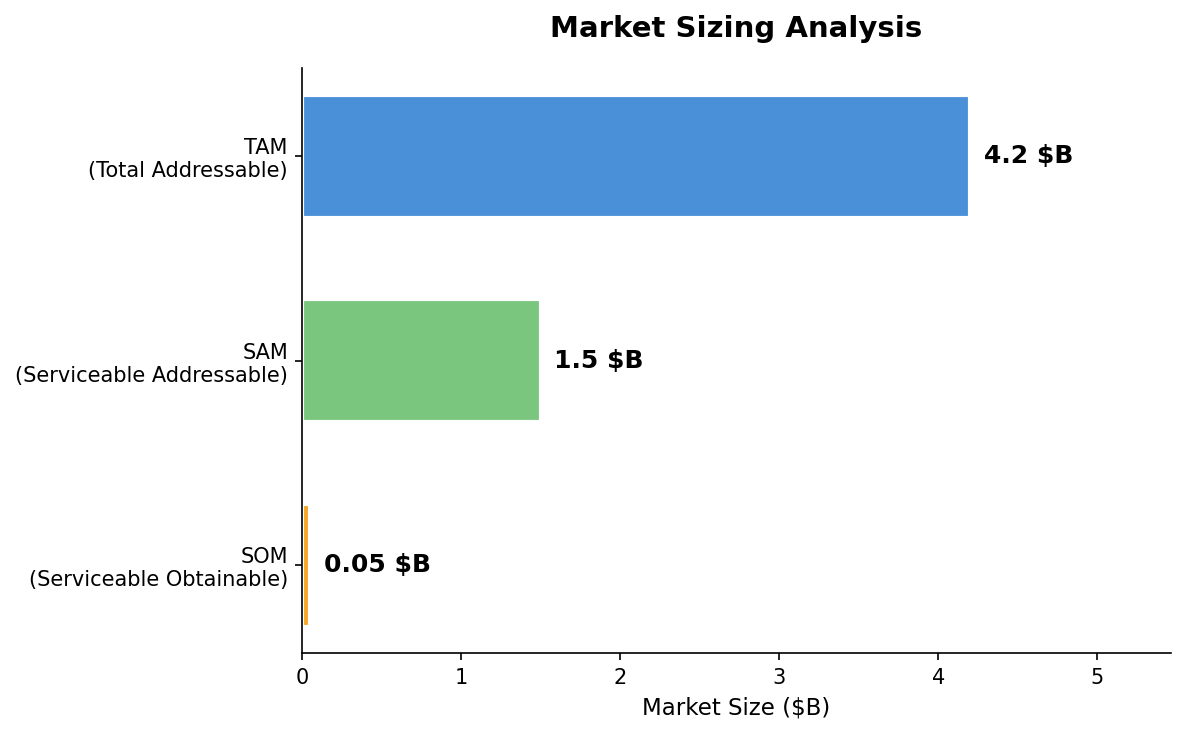

### Financial Projections

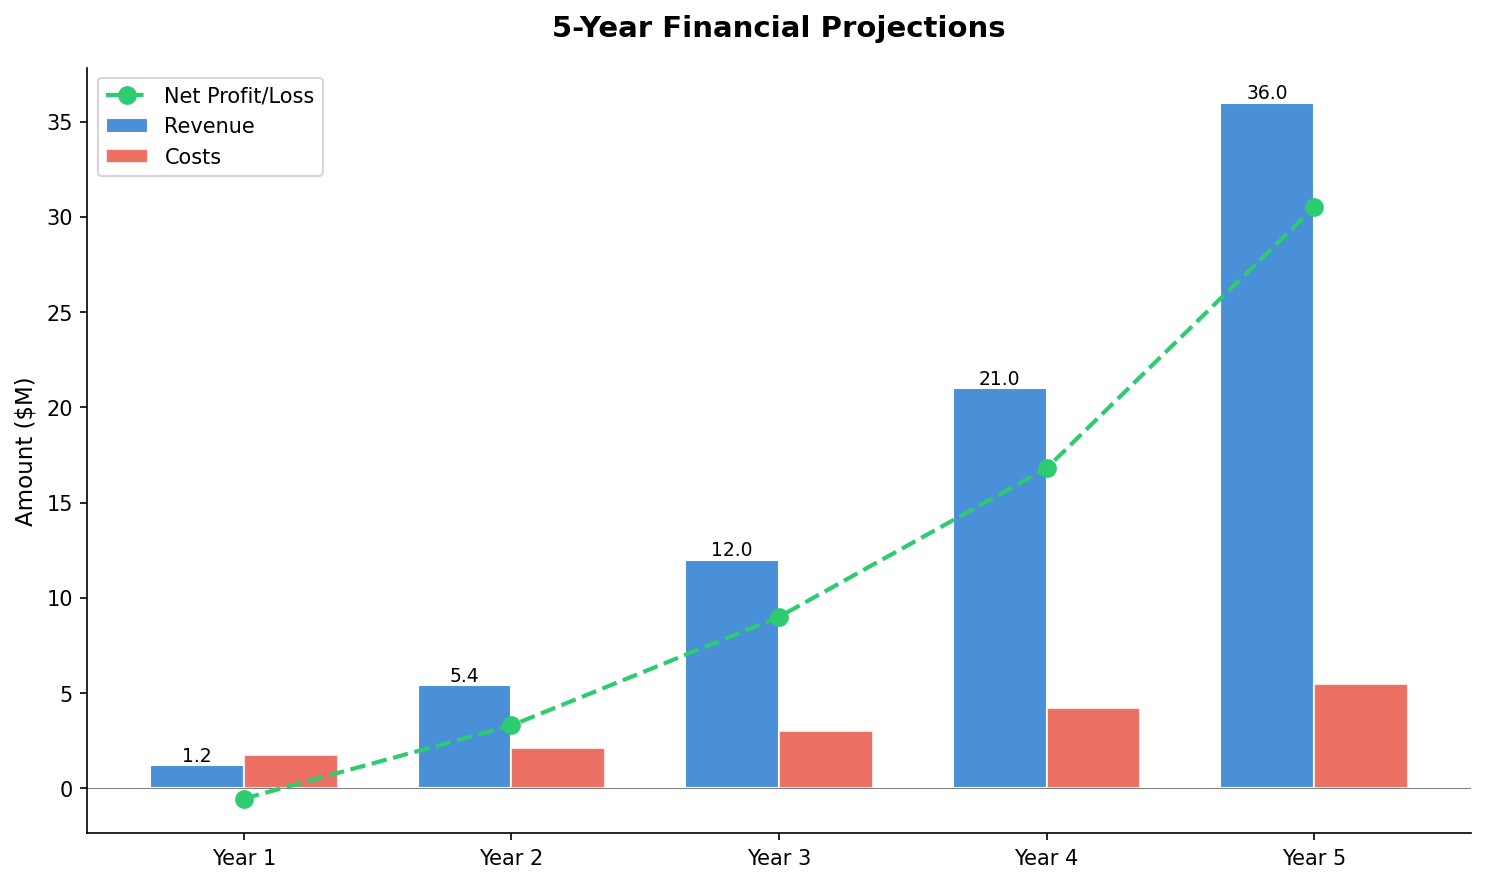

### Competitors

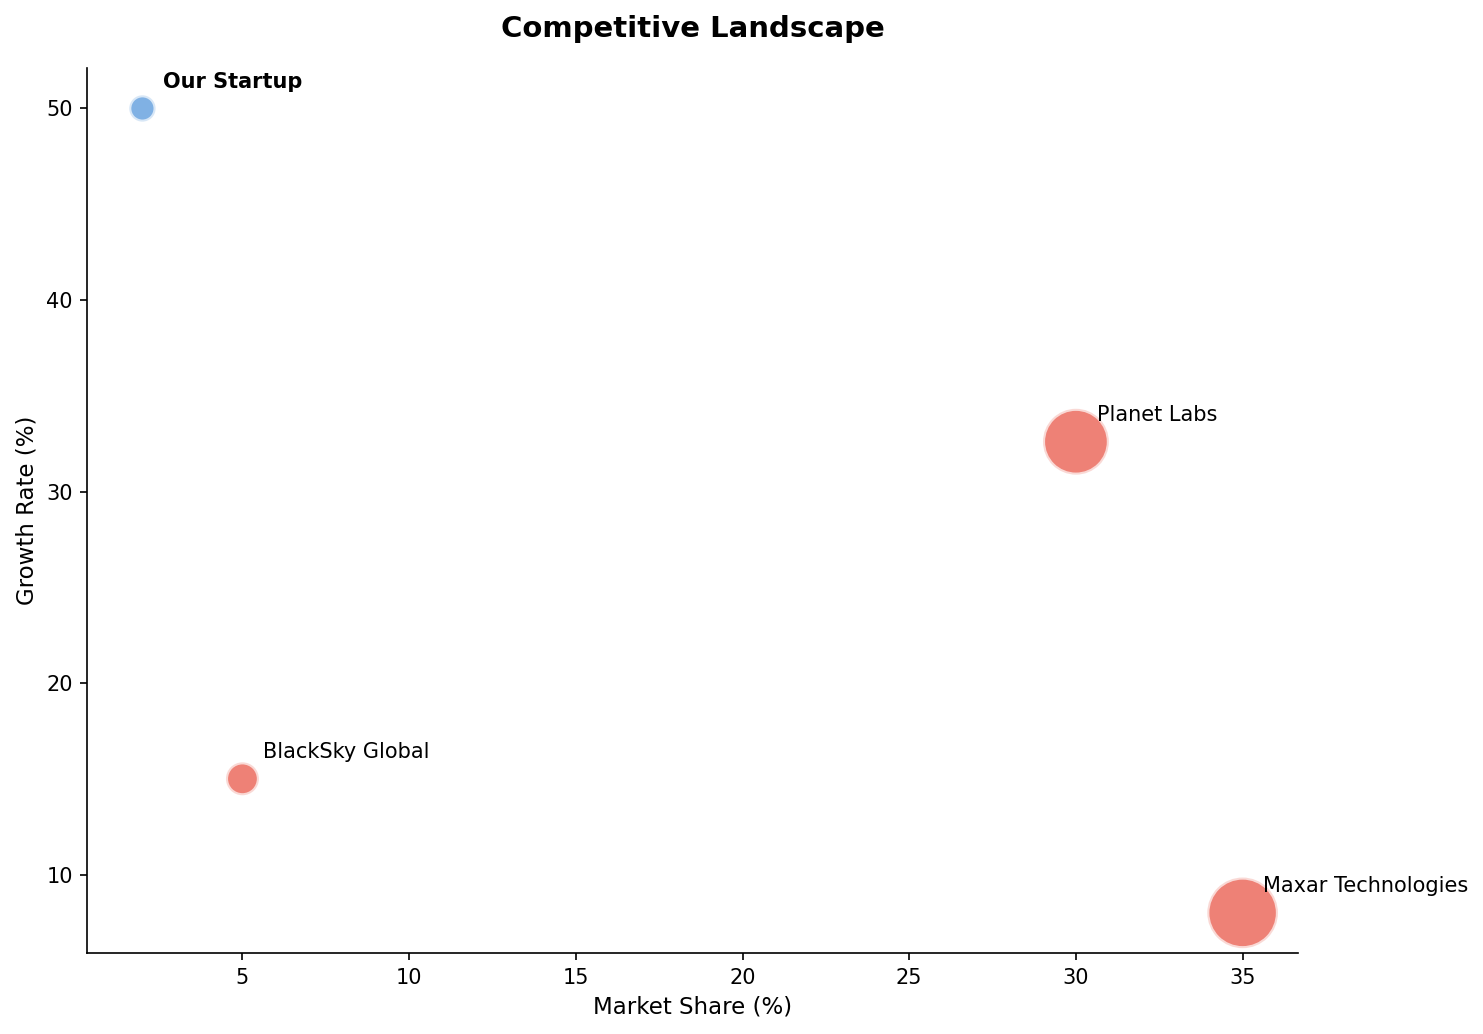

### Funding

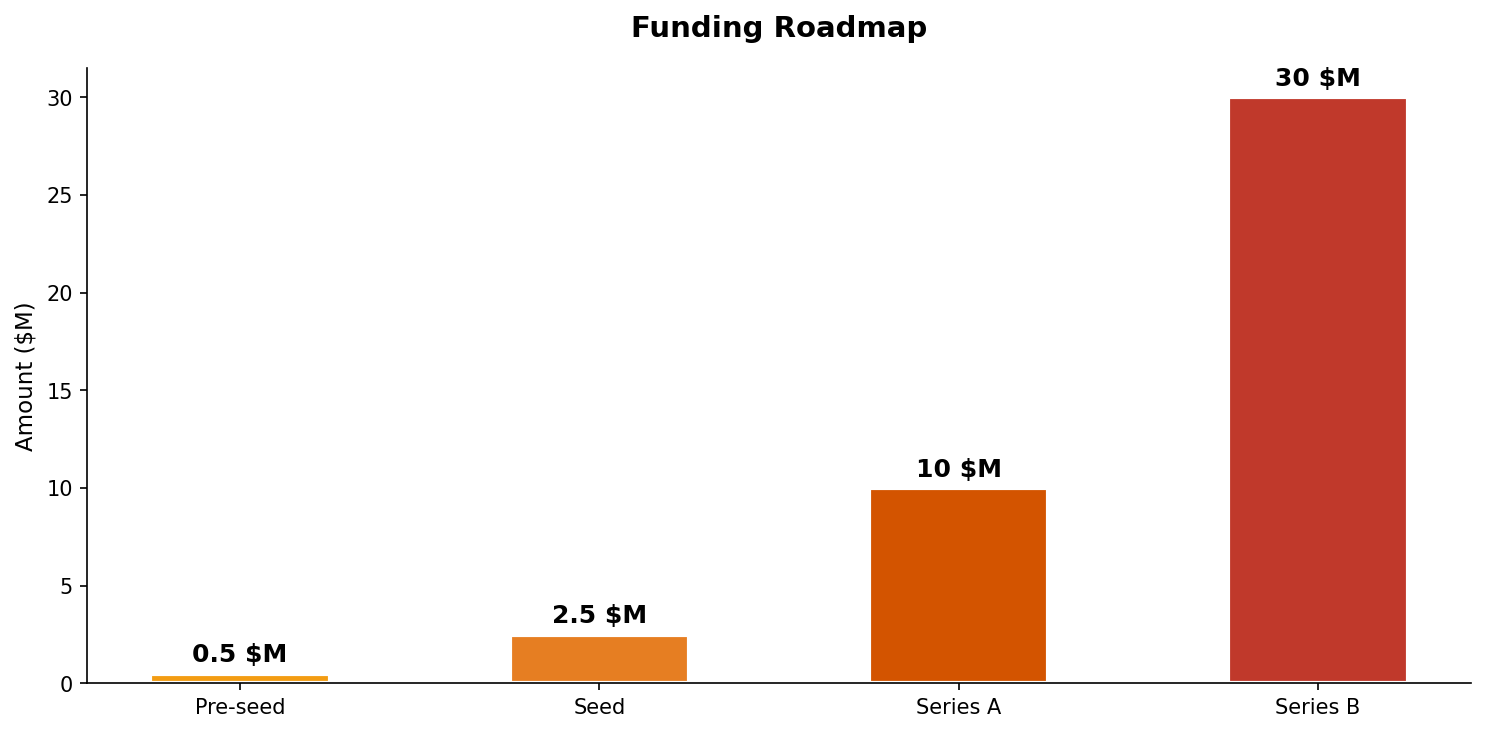

In [14]:
from IPython.display import Image, display, Markdown
import os

if chart_paths:
    for name, path in chart_paths.items():
        display(Markdown(f"### {name.replace('_', ' ').title()}"))
        if os.path.exists(path):
            display(Image(filename=path, width=700))
        else:
            print(f"  Chart file not found: {path}")
        print()
else:
    print("No charts were generated from pipeline. Showing reference charts below.")

## 10. Satellite Imagery Domain Charts (Reference)

Pre-built charts with satellite imagery market data.

In [15]:
from utils.plotting import generate_report_charts

satellite_chart_data = {
    "market_size": {
        "tam": 11.5,
        "sam": 3.8,
        "som": 0.15,
        "unit": "$B"
    },
    "financial_projections": {
        "years": [1, 2, 3, 4, 5],
        "revenue": [0.2, 0.8, 2.5, 6, 14],
        "costs": [1.2, 2, 3, 4.5, 7],
        "unit": "$M"
    },
    "competitors": {
        "names": ["Planet Labs", "Maxar", "BlackSky", "Satellogic", "Our Startup"],
        "market_share": [25, 30, 8, 5, 1],
        "growth_rate": [15, 8, 25, 30, 80]
    },
    "funding": {
        "rounds": ["Pre-seed", "Seed", "Series A", "Series B"],
        "amounts": [0.75, 4, 15, 40],
        "unit": "$M"
    }
}

reference_charts = generate_report_charts(satellite_chart_data)
print("Generated satellite imagery reference charts:")
for name, path in reference_charts.items():
    print(f"   - {name}: {path}")

Generated satellite imagery reference charts:
   - market_size: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/market_size.png
   - financial_projections: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/financial_projections.png
   - competitors: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/competitor_landscape.png
   - funding: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/funding_timeline.png


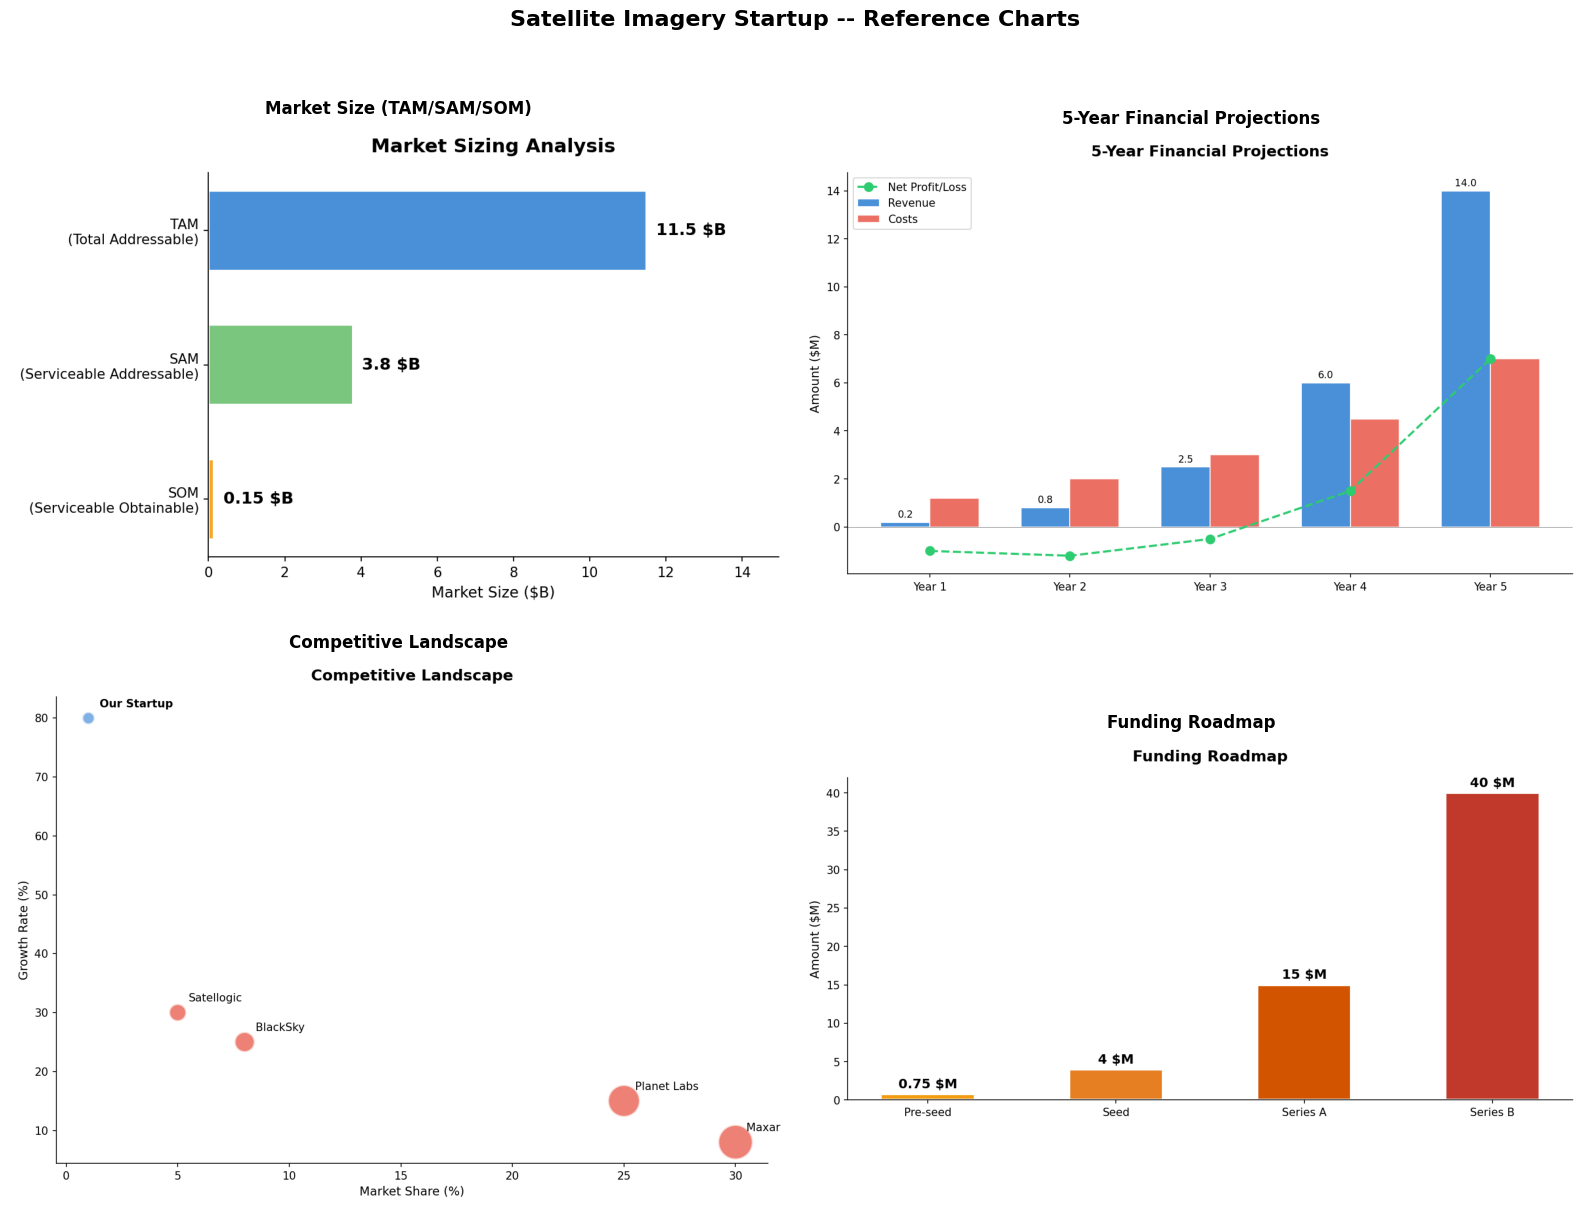

In [16]:
# Display all reference charts in a 2x2 grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Satellite Imagery Startup -- Reference Charts", fontsize=16, fontweight="bold", y=1.02)

chart_files = list(reference_charts.values())
titles = ["Market Size (TAM/SAM/SOM)", "5-Year Financial Projections",
          "Competitive Landscape", "Funding Roadmap"]

for ax, path, title in zip(axes.flat, chart_files, titles):
    img = plt.imread(path)
    ax.imshow(img)
    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.axis("off")

fig.tight_layout()
plt.show()

## 11. Pipeline Execution Timeline

Visualize how the parallel execution reduced total latency compared to sequential.

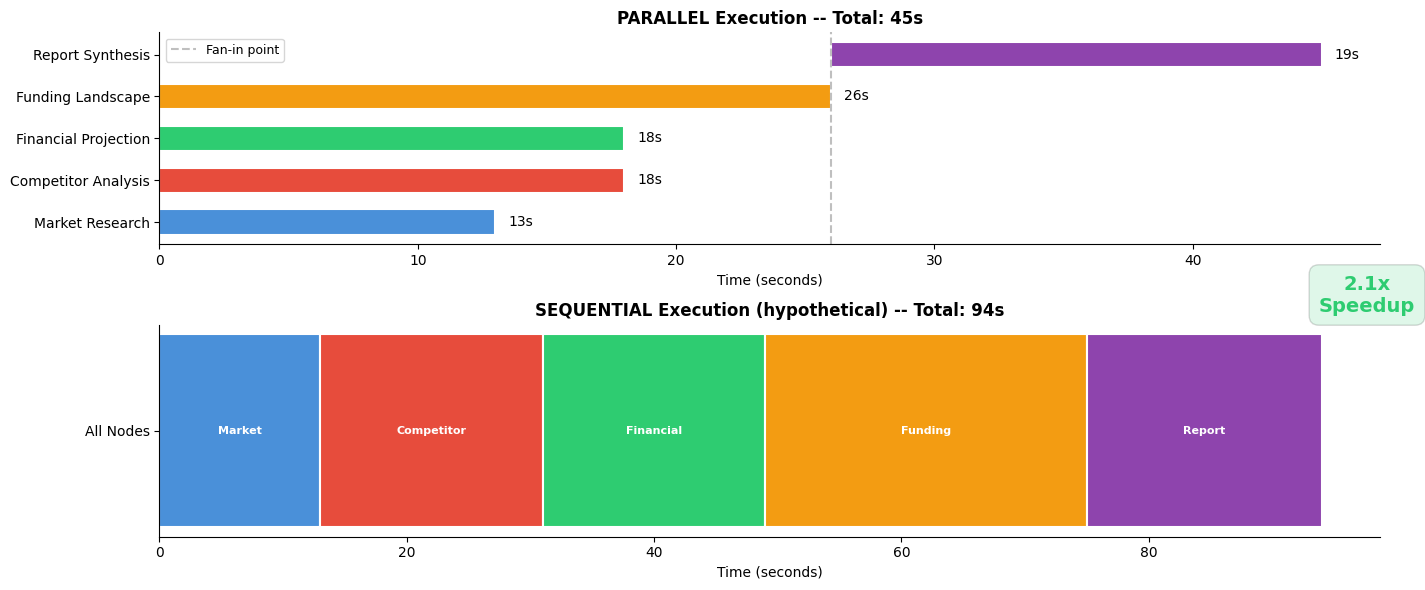

In [17]:
# Execution timeline visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 6), gridspec_kw={"height_ratios": [1, 1]})

colors = {"market_research": "#4A90D9", "competitor_analysis": "#E74C3C",
          "financial_projection": "#2ECC71", "funding_landscape": "#F39C12",
          "report_synthesis": "#8E44AD"}

labels = {"market_research": "Market Research", "competitor_analysis": "Competitor Analysis",
          "financial_projection": "Financial Projection", "funding_landscape": "Funding Landscape",
          "report_synthesis": "Report Synthesis"}

research_nodes = ["market_research", "competitor_analysis", "financial_projection", "funding_landscape"]

# Use actual durations if available, otherwise fallback
if node_timings:
    durations = {}
    for n in research_nodes:
        durations[n] = round(node_timings.get(n, 20))
    max_research_time = max(durations[n] for n in research_nodes)
    synthesis_time = round(node_timings.get("report_synthesis", 40) - max_research_time)
    durations["report_synthesis"] = max(synthesis_time, 5)
else:
    durations = {"market_research": 8, "competitor_analysis": 19,
                 "financial_projection": 13, "funding_landscape": 8, "report_synthesis": 21}

# --- PARALLEL timeline ---
for i, node in enumerate(research_nodes):
    ax1.barh(i, durations[node], color=colors[node], edgecolor="white", linewidth=1.5, height=0.6)
    ax1.text(durations[node] + 0.5, i, f"{durations[node]}s", va="center", fontsize=10)

max_research = max(durations[n] for n in research_nodes)
ax1.barh(4, durations["report_synthesis"], left=max_research,
         color=colors["report_synthesis"], edgecolor="white", linewidth=1.5, height=0.6)
ax1.text(max_research + durations["report_synthesis"] + 0.5, 4,
         f"{durations['report_synthesis']}s", va="center", fontsize=10)

ax1.set_yticks(range(5))
ax1.set_yticklabels([labels[n] for n in research_nodes] + [labels["report_synthesis"]], fontsize=10)
total_parallel = max_research + durations["report_synthesis"]
ax1.set_title(f"PARALLEL Execution -- Total: {total_parallel}s", fontsize=12, fontweight="bold")
ax1.set_xlabel("Time (seconds)")
ax1.axvline(x=max_research, color="gray", linestyle="--", alpha=0.5, label="Fan-in point")
ax1.legend(fontsize=9)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# --- SEQUENTIAL timeline (hypothetical) ---
cumulative = 0
sequential_order = research_nodes + ["report_synthesis"]
for i, node in enumerate(sequential_order):
    ax2.barh(0, durations[node], left=cumulative, color=colors[node],
             edgecolor="white", linewidth=1.5, height=0.6)
    ax2.text(cumulative + durations[node] / 2, 0, labels[node].split(" ")[0],
             ha="center", va="center", fontsize=8, color="white", fontweight="bold")
    cumulative += durations[node]

total_sequential = sum(durations.values())
ax2.set_title(f"SEQUENTIAL Execution (hypothetical) -- Total: {total_sequential}s", fontsize=12, fontweight="bold")
ax2.set_xlabel("Time (seconds)")
ax2.set_yticks([0])
ax2.set_yticklabels(["All Nodes"], fontsize=10)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Speedup annotation
speedup = total_sequential / total_parallel if total_parallel > 0 else 1
fig.text(0.98, 0.5, f"{speedup:.1f}x\nSpeedup", ha="center", va="center",
         fontsize=14, fontweight="bold", color="#2ECC71",
         bbox=dict(boxstyle="round,pad=0.5", facecolor="#2ECC71", alpha=0.15))

fig.tight_layout()
plt.show()

## 12. Save Final Report to File

In [18]:
output_dir = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(output_dir, exist_ok=True)

report_path = os.path.join(output_dir, "satellite_imagery_startup_plan.md")

report_content = get_node_content("report_synthesis")
if report_content and report_content != "No output available.":
    report_md = "# Satellite Imagery Startup Plan\n\n"
    report_md += "*Generated by LangGraph Parallel Planning Pipeline*\n\n---\n\n"
    report_md += report_content

    if chart_paths or reference_charts:
        report_md += "\n\n---\n## Generated Charts\n\n"
        paths_to_use = chart_paths if chart_paths else reference_charts
        for name, path in paths_to_use.items():
            fname = os.path.basename(path)
            report_md += f"### {name.replace('_', ' ').title()}\n"
            report_md += f"![{name}]({fname})\n\n"

    with open(report_path, "w") as f:
        f.write(report_md)
    print(f"Report saved to: {report_path}")
else:
    print("No report content to save -- run the pipeline first (Section 6).")

print(f"\nOutput directory contents:")
for f in sorted(os.listdir(output_dir)):
    fpath = os.path.join(output_dir, f)
    size_kb = os.path.getsize(fpath) / 1024
    print(f"   - {f} ({size_kb:.1f} KB)")

Report saved to: /Users/soumendusekharbhattacharjee/Documents/DATA-SCIENCE/Langgraph_Skills_MCP/outputs/satellite_imagery_startup_plan.md

Output directory contents:
   - competitor_landscape.png (50.2 KB)
   - financial_projections.png (48.2 KB)
   - funding_timeline.png (30.7 KB)
   - market_size.png (36.8 KB)
   - satellite_imagery_startup_plan.md (8.5 KB)
